In [139]:
import sys
sys.path.append('..')

In [140]:
import pandas as pd
from utils.data_enedis_ademe import DataEnedisAdeme

#### Consommation d'électricité annuelle résidentielle par adresse

*Le jeu de données présente la consommation électrique annuelle des adresses de 10 logements ou plus. Un logement correspond à un point de livraison (ou PDL) de type résidentiel.<br>Les données sont mises à disposition à titre purement indicatif sans garantie quant au degré de fiabilité des adresses. Enedis ne saurait, par conséquent, être tenue responsable en cas de défaut de fiabilité.<br>À partir de 2021 et suite à un changement dans le référentiel des adresses, la normalisation de celles-ci peut faire apparaitre des écarts avec les années précédentes.*

In [141]:
tmp_url = "https://data.enedis.fr/api/explore/v2.1/catalog/datasets/consommation-annuelle-residentielle-par-adresse/records?select=segment_de_client%2C%20annee%2C%20count\
    (code_iris)%20as%20nb%2C%20min(nombre_de_logements)%20as%20nb_min_logements%2C%20max(nombre_de_logements)%20as%20nb_max_logements&group_by=segment_de_client%2C%20annee&limit=20"

DataEnedisAdeme().load_get_data_pandas(tmp_url)

,segment_de_client,annee,nb,nb_min_logements,nb_max_logements
0,RESIDENTIEL,2018-01-01T00:00:00+00:00,391099,10,1189
1,RESIDENTIEL,2019-01-01T00:00:00+00:00,399791,10,1124
2,RESIDENTIEL,2020-01-01T00:00:00+00:00,405605,10,1435
3,RESIDENTIEL,2021-01-01T00:00:00+00:00,407053,10,1189
4,RESIDENTIEL,2022-01-01T00:00:00+00:00,394100,10,1190
5,RESIDENTIEL,2023-01-01T00:00:00+00:00,397398,10,1196


*Avec ceci on voit que les adresses Enedis sont des logements 'residentiels' avec au moins 10 logements et au plus +de 1000 logements. Une fois la correspondance faite avec la base de l'ADEME - DPE depuis 2021 on le dataset suivant :*

In [142]:
db = DataEnedisAdeme()
tmp_df = db.extract_sample_year_rows(year=2023, rows=5)
tmp_df.head(3)

 https://data.enedis.fr/api/explore/v2.1/catalog/datasets/consommation-annuelle-residentielle-par-adresse/records?where=annee%20%3D%20date'2023'&limit=5


,Conso_chauffage_dépensier_é_finale_ademe,Nom__commune_(BAN)_ademe,Emission_GES_chauffage_ademe,Conso_ECS_é_finale_énergie_n°2_ademe,Conso_ECS_é_finale_énergie_n°1_ademe,Besoin_refroidissement_ademe,Coût_total_5_usages_ademe,Coordonnée_cartographique_X_(BAN)_ademe,Nombre_niveau_logement_ademe,Apports_internes_saison_froid_ademe,...,x_enedis_with_ban,y_enedis_with_ban,city_enedis_with_ban,context_enedis_with_ban,type_enedis_with_ban,importance_enedis_with_ban,street_enedis_with_ban,lon_enedis_with_ban,lat_enedis_with_ban,_type_enedis_with_ban
0,14842.3,Cavaillon,3195.3,1704.1,1704.1,0,1846.3,864217.4,1,0.0,...,864217.4,6306054.04,Cavaillon,"84, Vaucluse, Provence-Alpes-Côte d'Azur",housenumber,0.65173,Avenue du Maréchal Joffre,5.041736,43.834389,NaN
1,8112.0,Cavaillon,604.4,NaN,1632.0,0,1572.0,864217.4,1,0.0,...,864217.4,6306054.04,Cavaillon,"84, Vaucluse, Provence-Alpes-Côte d'Azur",housenumber,0.65173,Avenue du Maréchal Joffre,5.041736,43.834389,NaN
2,11200.8,Cavaillon,2415.7,0.0,1863.6,0,1125.0,864217.4,1,0.0,...,864217.4,6306054.04,Cavaillon,"84, Vaucluse, Provence-Alpes-Côte d'Azur",housenumber,0.65173,Avenue du Maréchal Joffre,5.041736,43.834389,NaN


*Echantillon pour l'étude : périmètre Paris 2018*

In [143]:
df = pd.read_parquet('../ressources/data/2_intermediary/enedis_ban_ademe_extract_PARIS_2018_400k_rows_250_min_comp.parquet', engine='pyarrow')
df.head()

,Conso_chauffage_dépensier_é_finale_ademe,Volume_stockage_générateur_ECS_n°1_ademe,Conso_é_finale_installation_ECS_ademe,Nom__commune_(BAN)_ademe,Emission_GES_chauffage_ademe,Conso_ECS_é_finale_énergie_n°2_ademe,Conso_ECS_é_finale_énergie_n°1_ademe,Besoin_refroidissement_ademe,Conso_chauffage_dépensier_installation_chauffage_n°1_ademe,Coût_total_5_usages_ademe,...,y_enedis_with_ban,city_enedis_with_ban,district_enedis_with_ban,context_enedis_with_ban,type_enedis_with_ban,importance_enedis_with_ban,street_enedis_with_ban,lon_enedis_with_ban,lat_enedis_with_ban,_type_enedis_with_ban
0,16170.8,0.0,1548.3,Paris,2987.6,0.0,1548.3,0,16170.8,1083.0,...,6866570.89,Paris,Paris 17e Arrondissement,"75, Paris, Île-de-France",housenumber,0.66547,Passage Flourens,2.327087,48.897252,None
1,20081.5,0.0,5617.0,Paris,3737.2,0.0,5617.0,0,20081.5,2150.5,...,6866570.89,Paris,Paris 17e Arrondissement,"75, Paris, Île-de-France",housenumber,0.66547,Passage Flourens,2.327087,48.897252,None
2,38501.7,0.0,5812.1,Paris,10285.3,0.0,5812.1,0,38501.7,3529.6,...,6863733.09,Paris,Paris 16e Arrondissement,"75, Paris, Île-de-France",housenumber,0.77255,Avenue Foch,2.278373,48.871447,address
3,39468.7,0.0,6130.1,Paris,10508.7,0.0,6130.1,0,39468.7,3637.1,...,6863733.09,Paris,Paris 16e Arrondissement,"75, Paris, Île-de-France",housenumber,0.77255,Avenue Foch,2.278373,48.871447,address
4,15376.1,0.0,5752.4,Paris,2816.4,0.0,5752.4,0,15376.1,1186.5,...,6863783.96,Paris,Paris 16e Arrondissement,"75, Paris, Île-de-France",housenumber,0.77255,Avenue Foch,2.282777,48.871931,None


# Exploration

In [144]:
class preprocessing :
    def __init__(self, df):
        self.df = df.copy()
        
    def get_entropy(pk, L):
        op = - (pk * np.log(pk) / np.log(L)).sum()
        return op 

    def delete_colnan (self, tauxseuil):
        print("Le dataframe contient initialement {} colonnes et {}".format(len(self.df.columns), len(self.df)))
        print("Start processing : columns identification ...")
        nanames = []
        entro = []
        extra = []
        for c in self.df.columns:
            tauxnan = round(self.df[c].isna().sum()/len(self.df),2)
            pk = df[c].value_counts(normalize=True, dropna = False).values
            entropy = round(get_entropy(pk, len(self.df)),2)
            if tauxnan >= tauxseuil:
                nanames.append(c)
                # print("***", c, "***")
                # print(tauxnan)
            if c[0]=="_":
                extra.append(c)
            if entropy == 1 or entropy == 0:
                entro.append(c)
        print("Il y a {} colonnes vides avec au moins {}% , {} colonnes avec une entropy de 1 ou 0 et {} colonnes inutiles".format(len(nanames),tauxseuil*100, len(entro), len(extra)))
        print("Start processing : columns deleting ...")
        df_clean=self.df.drop(nanames+entro+extra, axis=1)
        print("Done")
        print("Il reste {} colonnes".format(len(df_clean)))
        return df_clean.drop_duplicates()
    


In [145]:
# recherches des valeurs manquantes
def get_entropy(pk, L):
    op = - (pk * np.log(pk) / np.log(L)).sum()
    return op

tauxseuil = 0.9
nanames = []
entro = []
extra =[]
print("Le dataframe contient initialement {} colonnes et {}".format(len(df.columns), len(df)))
for c in df.columns:
    tauxnan = round(df[c].isna().sum()/len(df),2)
    pk = df[c].value_counts(normalize=True, dropna = False).values
    entropy = round(get_entropy(pk, len(df)),2)
    if tauxnan >= tauxseuil:
        nanames.append(c)
    if c[0]=="_":
        # print(c)
        extra.append(c)
        #print("***", c, "***")
        #print(tauxnan)
    if entropy == 1 or entropy == 0:
        # print(c, entropy)
        nanames.append(c)
        entro.append(c)
print("Il y a {} colonnes vides avec au moins {}% , {} colonnes avec une entropy de 1 ou 0 et {} colonnes inutiles.".format(len(nanames),tauxseuil*100, len(entro), len(extra)))
# print(len(df.columns))
# print(nanames)
df_clean = df.copy().drop(nanames+entro+extra, axis=1).drop_duplicates()
print("Il reste {} colonnes et {} lignes.".format(len(df_clean.columns),len(df_clean)))

Le dataframe contient initialement 280 colonnes et 465961
Il y a 131 colonnes vides avec au moins 90.0% , 55 colonnes avec une entropy de 1 ou 0 et 6 colonnes inutiles.
Il reste 182 colonnes et 437073 lignes.


In [146]:
round(df_clean.describe(),2)

,Conso_chauffage_dépensier_é_finale_ademe,Volume_stockage_générateur_ECS_n°1_ademe,Conso_é_finale_installation_ECS_ademe,Emission_GES_chauffage_ademe,Conso_ECS_é_finale_énergie_n°2_ademe,Conso_ECS_é_finale_énergie_n°1_ademe,Conso_chauffage_dépensier_installation_chauffage_n°1_ademe,Coût_total_5_usages_ademe,Conso_é_finale_dépensier_installation_ECS_ademe,Surface_chauffée_installation_chauffage_n°1_ademe,...,Nombre de logements_enedis_with_ban,Consommation annuelle totale de l'adresse (MWh)_enedis_with_ban,Consommation annuelle moyenne par logement de l'adresse (MWh)_enedis_with_ban,Tri des adresses_enedis_with_ban,score_enedis_with_ban,x_enedis_with_ban,y_enedis_with_ban,importance_enedis_with_ban,lon_enedis_with_ban,lat_enedis_with_ban
count,437073.00,423950.00,423950.00,437073.00,258912.0,437073.00,425982.00,437071.00,423950.00,425982.00,...,437073.00,437073.00,437073.00,437073.00,437073.00,437073.00,437073.00,437073.00,437073.00,437073.00
mean,14147.95,157.96,64595.94,2097.43,665.9,3095.25,270047.45,1673.14,90104.70,1578.55,...,43.57,110.68,2.94,653854.06,0.74,651869.26,6862378.35,0.74,2.34,48.86
std,77501.99,684.69,177408.52,12689.98,6651.0,19076.08,793201.39,8046.32,248382.41,3918.16,...,50.49,113.65,1.51,14330.55,0.03,2971.42,2370.13,0.06,0.04,0.02
min,0.00,0.00,0.00,0.00,0.0,0.00,1.00,41.00,0.00,0.30,...,10.00,0.50,0.03,628981.00,0.45,645307.24,6857682.68,0.48,2.25,48.82
25%,3676.60,0.00,1417.30,255.50,0.0,1261.00,4018.72,681.10,1839.70,30.50,...,18.00,48.07,1.87,641465.00,0.72,649376.14,6860383.33,0.69,2.31,48.84
50%,6653.70,50.00,1877.85,701.00,0.0,1667.80,8227.60,972.20,2448.45,53.00,...,27.00,75.08,2.66,653981.00,0.74,652122.35,6862247.92,0.74,2.35,48.86
75%,12172.40,100.00,4764.30,1956.40,0.0,2265.40,24591.02,1353.45,6580.12,439.30,...,46.00,126.65,3.54,666388.00,0.75,654317.59,6864487.26,0.79,2.38,48.88
max,7108617.20,65000.00,2154610.20,1177726.80,605106.4,2154610.20,6782825.60,751160.00,3039539.30,39182.00,...,484.00,1368.30,21.61,679041.00,0.81,657143.08,6867011.10,0.85,2.42,48.90


In [147]:
object_columns = df_clean.select_dtypes(include=['object']).columns
print(len(object_columns))
df_clean[object_columns].head(20)

75


,Besoin_refroidissement_ademe,Configuration_installation_chauffage_n°1_ademe,Configuration_installation_ECS_ademe,Type_installation_chauffage_n°1_ademe,Type_installation_ECS_(général)_ademe,Usage_générateur_ECS_n°1_ademe,Adresse_(BAN)_ademe,Date_visite_diagnostiqueur_ademe,Type_énergie_générateur_ECS_n°1_ademe,Complément_d'adresse_logement_ademe,...,full_adress_enedis_with_ban,label_enedis_with_ban,housenumber_enedis_with_ban,id_BAN_enedis_with_ban,name_enedis_with_ban,postcode_enedis_with_ban,citycode_enedis_with_ban,district_enedis_with_ban,type_enedis_with_ban,street_enedis_with_ban
0,0,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation collective,individuel,ecs,3 Passage Flourens 75017 Paris,2023-05-25,Gaz naturel,2 éme étage porte gauche,...,3 PASSAGE FLOURENS 75056 PARIS,3 PASSAGE FLOURENS 75017 PARIS,3,75117_3694_00003,3 Passage Flourens,75017,75117,Paris 17e Arrondissement,housenumber,Passage Flourens
1,0,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation collective,collectif,chauffage + ecs,3 Passage Flourens 75017 Paris,2024-07-14,Gaz naturel,"4ème étage, porte droite",...,3 PASSAGE FLOURENS 75056 PARIS,3 PASSAGE FLOURENS 75017 PARIS,3,75117_3694_00003,3 Passage Flourens,75017,75117,Paris 17e Arrondissement,housenumber,Passage Flourens
2,0,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation collective,collectif,chauffage + ecs,77 Avenue Foch 75016 Paris,2023-05-29,Fioul domestique,Etage : 3,...,77 AVENUE FOCH 75056 PARIS,77 AVENUE FOCH 75016 PARIS,77,75116_3696_00077,77 Avenue Foch,75016,75116,Paris 16e Arrondissement,housenumber,Avenue Foch
3,0,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation collective,collectif,chauffage + ecs,77 Avenue Foch 75016 Paris,2024-06-17,Fioul domestique,Etage : 3,...,77 AVENUE FOCH 75056 PARIS,77 AVENUE FOCH 75016 PARIS,77,75116_3696_00077,77 Avenue Foch,75016,75116,Paris 16e Arrondissement,housenumber,Avenue Foch
4,0,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation collective,collectif,chauffage + ecs,49 Avenue Foch 75016 Paris,2023-03-01,Gaz naturel,Esc. D; Etage 3,...,49 AVENUE FOCH 75056 PARIS,49 AVENUE FOCH 75016 PARIS,49,75116_3696_00049,49 Avenue Foch,75016,75116,Paris 16e Arrondissement,housenumber,Avenue Foch
5,0,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation collective,collectif,chauffage,49 Avenue Foch 75016 Paris,2021-12-02,Gaz naturel,Bat. Rue; Esc. C; Etage 4; Porte face,...,49 AVENUE FOCH 75056 PARIS,49 AVENUE FOCH 75016 PARIS,49,75116_3696_00049,49 Avenue Foch,75016,75116,Paris 16e Arrondissement,housenumber,Avenue Foch
6,"184,9",Installation de chauffage simple,Un seul système d'ECS sans solaire,installation collective,collectif,chauffage + ecs,49 Avenue Foch 75016 Paris,2023-05-01,Gaz naturel,Etage : 5G,...,49 AVENUE FOCH 75056 PARIS,49 AVENUE FOCH 75016 PARIS,49,75116_3696_00049,49 Avenue Foch,75016,75116,Paris 16e Arrondissement,housenumber,Avenue Foch
7,0,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation collective,collectif,chauffage + ecs,49 Avenue Foch 75016 Paris,2023-04-19,Gaz naturel,bat C 3Eme etage,...,49 AVENUE FOCH 75056 PARIS,49 AVENUE FOCH 75016 PARIS,49,75116_3696_00049,49 Avenue Foch,75016,75116,Paris 16e Arrondissement,housenumber,Avenue Foch
8,0,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation collective,collectif,chauffage + ecs,49 Avenue Foch 75016 Paris,2024-01-29,Gaz naturel,Etage : 2,...,49 AVENUE FOCH 75056 PARIS,49 AVENUE FOCH 75016 PARIS,49,75116_3696_00049,49 Avenue Foch,75016,75116,Paris 16e Arrondissement,housenumber,Avenue Foch
9,0,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation collective,collectif,chauffage + ecs,49 Avenue Foch 75016 Paris,2023-01-23,Gaz naturel,Rez-de-chaussée,...,49 AVENUE FOCH 75056 PARIS,49 AVENUE FOCH 75016 PARIS,49,75116_3696_00049,49 A

In [148]:
int_columns = df_clean.select_dtypes(include=['int']).columns
print(len(int_columns))
df_clean[int_columns].head(20)

3


,Numéro de voie_enedis_with_ban,Nombre de logements_enedis_with_ban,Tri des adresses_enedis_with_ban
0,3,14,660005
1,3,14,660005
2,77,14,660013
3,77,14,660013
4,49,89,660026
5,49,89,660026
6,49,89,660026
7,49,89,660026
8,49,89,660026
9,49,89,660026


In [149]:
float_columns = df_clean.select_dtypes(include=['float']).columns
print(len(float_columns))
df_clean[float_columns].head(20)

104


,Conso_chauffage_dépensier_é_finale_ademe,Volume_stockage_générateur_ECS_n°1_ademe,Conso_é_finale_installation_ECS_ademe,Emission_GES_chauffage_ademe,Conso_ECS_é_finale_énergie_n°2_ademe,Conso_ECS_é_finale_énergie_n°1_ademe,Conso_chauffage_dépensier_installation_chauffage_n°1_ademe,Coût_total_5_usages_ademe,Conso_é_finale_dépensier_installation_ECS_ademe,Surface_chauffée_installation_chauffage_n°1_ademe,...,Année_construction_ademe,Nombre_niveau_immeuble_ademe,Consommation annuelle totale de l'adresse (MWh)_enedis_with_ban,Consommation annuelle moyenne par logement de l'adresse (MWh)_enedis_with_ban,score_enedis_with_ban,x_enedis_with_ban,y_enedis_with_ban,importance_enedis_with_ban,lon_enedis_with_ban,lat_enedis_with_ban
0,16170.8,0.0,1548.3,2987.6,0.0,1548.3,16170.8,1083.0,2120.2,42.1,...,NaN,NaN,23.715,1.694,0.725270,650664.97,6866570.89,0.66547,2.327087,48.897252
1,20081.5,0.0,5617.0,3737.2,0.0,5617.0,20081.5,2150.5,7259.4,37.7,...,NaN,NaN,23.715,1.694,0.725270,650664.97,6866570.89,0.66547,2.327087,48.897252
2,38501.7,0.0,5812.1,10285.3,0.0,5812.1,38501.7,3529.6,7072.2,102.0,...,NaN,NaN,41.505,2.965,0.767202,647067.35,6863733.09,0.77255,2.278373,48.871447
3,39468.7,0.0,6130.1,10508.7,0.0,6130.1,39468.7,3637.1,7519.6,124.0,...,NaN,NaN,41.505,2.965,0.767202,647067.35,6863733.09,0.77255,2.278373,48.871447
4,15376.1,0.0,5752.4,2816.4,0.0,5752.4,15376.1,1186.5,7750.9,60.2,...,NaN,NaN,138.919,1.561,0.767202,647390.87,6863783.96,0.77255,2.282777,48.871931
5,4292.4,0.0,1.0,768.4,1286.4,1286.4,1.0,391.8,1.0,28.2,...,1947.0,NaN,138.919,1.561,0.767202,647390.87,6863783.96,0.77255,2.282777,48.871931
6,14566.5,0.0,2638.6,2642.3,0.0,2638.6,14566.5,951.4,3674.1,63.3,...,NaN,NaN,138.919,1.561,0.767202,647390.87,6863783.96,0.77255,2.282777,48.871931
7,7836.0,0.0,5224.8,1408.4,0.0,5224.8,7836.0,770.7,7276.0,64.8,...,1965.0,NaN,138.919,1.561,0.767202,647390.87,6863783.96,0.77255,2.282777,48.871931
8,11509.5,0.0,2584.0,1976.1,0.0,2584.0,10475.8,1075.5,3593.1,54.5,...,NaN,NaN,138.919,1.561,0.767202,647390.87,6863783.96,0.77255,2.282777,48.871931
9,10010.7,0.0,5605.7,1796.5,0.0,5605.7,10010.7,1056.5,7557.3,56.0,...,NaN,NaN,138.919,1.561,0.767202,647390.87,6863783.96,0.77255,2.282777,48.871931


In [152]:
import numpy as np
def get_entropy(pk, L):
        op = - (pk * np.log(pk) / np.log(L)).sum()
        return op 
# pk : probabilité de chaque valeur
# L : nombre de valeurs possibles
# d : dataframe
# cols : liste des colonnes à traiter

def compute_entropies(d, cols):
    entropies = []
    for i,col in enumerate(cols):
        pk = d[col].value_counts(normalize=True, dropna = False).values
        entropy = round(get_entropy(pk, len(d)),3)
        entropies.append({"col": col, "entropy": entropy})
    return entropies      

df_entropy = pd.DataFrame(compute_entropies(df_clean, df_clean.columns))

In [153]:
df_entropy.sort_values(by="entropy", ascending=True).head(50)


,col,entropy
177,type_enedis_with_ban,0.004
76,Emission_GES_refroidissement_ademe,0.007
96,Type_bâtiment_ademe,0.007
95,Emission_GES_refroidissement_dépensier_ademe,0.008
20,Coût_refroidissement_ademe,0.008
65,Conso_refroidissement_é_primaire_ademe,0.009
92,Coût_refroidissement_dépensier_ademe,0.009
46,Conso_refroidissement_é_finale_ademe,0.009
130,Conso_refroidissement_dépensier_é_primaire_ademe,0.010
105,Conso_refroidissement_dépensier_é_finale_ademe,0.010


In [158]:
round(df_clean["Type_bâtiment_ademe"].value_counts(normalize=True, dropna = False),2)

Type_bâtiment_ademe
appartement    0.98
immeuble       0.01
maison         0.00
Name: proportion, dtype: float64

In [130]:
for c in df_clean.columns:
    if "ar" in c.lower():
        print(c)

Coordonnée_cartographique_X_(BAN)_ademe
Conso_5_usages_par_m²_é_primaire_ademe
Emission_GES_5_usages_par_m²_ademe
N°_étage_appartement_ademe
Surface_habitable_desservie_par_installation_ECS_ademe
Nombre_appartement_ademe
Nombre_logements_desservis_par_installation_ECS_ademe
Coordonnée_cartographique_Y_(BAN)_ademe
Appartement_non_visité_(0/1)_ademe
Consommation annuelle moyenne par logement de l'adresse (MWh)_enedis_with_ban


In [45]:
df_clean.iloc[:,0:100].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 465961 entries, 0 to 465960
Data columns (total 100 columns):
 #   Column                                                       Non-Null Count   Dtype  
---  ------                                                       --------------   -----  
 0   Conso_chauffage_dépensier_é_finale_ademe                     465961 non-null  float64
 1   Volume_stockage_générateur_ECS_n°1_ademe                     452514 non-null  float64
 2   Conso_é_finale_installation_ECS_ademe                        452514 non-null  float64
 3   Nom__commune_(BAN)_ademe                                     465961 non-null  object 
 4   Emission_GES_chauffage_ademe                                 465961 non-null  float64
 5   Conso_ECS_é_finale_énergie_n°2_ademe                         285178 non-null  float64
 6   Conso_ECS_é_finale_énergie_n°1_ademe                         465961 non-null  float64
 7   Besoin_refroidissement_ademe                                 464

In [54]:
df_clean.iloc[:,100:200].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 465961 entries, 0 to 465960
Data columns (total 100 columns):
 #   Column                                                                         Non-Null Count   Dtype  
---  ------                                                                         --------------   -----  
 0   Date_fin_validité_DPE_ademe                                                    465961 non-null  object 
 1   Deperditions_planchers_hauts_ademe                                             464857 non-null  float64
 2   Emission_GES_refroidissement_dépensier_ademe                                   465961 non-null  float64
 3   Type_bâtiment_ademe                                                            465961 non-null  object 
 4   Apports_solaires_saison_chauffe_ademe                                          464857 non-null  float64
 5   Conso_chauffage_générateur_n°1_installation_n°1_ademe                          454586 non-null  float64
 6   Coût_chauff

In [56]:
df_clean.iloc[:,200:205].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 465961 entries, 0 to 465960
Data columns (total 4 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   street_enedis_with_ban  465961 non-null  object 
 1   lon_enedis_with_ban     465961 non-null  float64
 2   lat_enedis_with_ban     465961 non-null  float64
 3   _type_enedis_with_ban   79455 non-null   object 
dtypes: float64(2), object(2)
memory usage: 14.2+ MB


In [60]:
df_clean["_rand_ademe"].head()

0    712091
1    928729
2    840575
3    398786
4    902234
Name: _rand_ademe, dtype: int64

<BarContainer object of 7 artists>

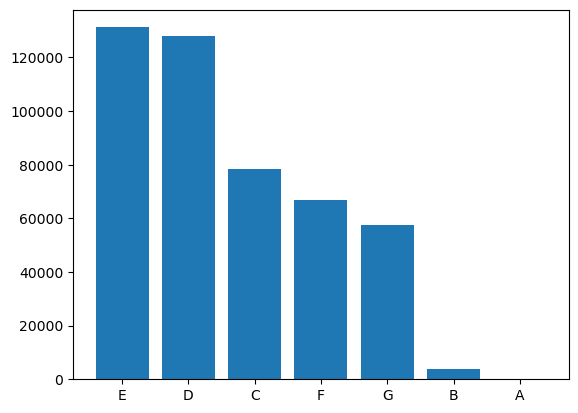

In [33]:
# distribution des logements en fonction des DPE
import matplotlib.pyplot as plt
import numpy as np

DPE = df_clean["Etiquette_DPE_ademe"].value_counts().index
count = df_clean["Etiquette_DPE_ademe"].value_counts()
fig, ax = plt.subplots()
ax.bar(DPE,count)

In [54]:
df["Consommation annuelle moyenne par logement de l'adresse (MWh)_enedis_with_ban"].values

array([1.694, 1.694, 2.965, ..., 3.132, 3.132, 3.132])

In [ ]:
fig, ax = plt.subplots()             # Create a figure containing a single Axes.
ax.plot([1, 2, 3, 4], [1, 4, 2, 3])  # Plot some data on the Axes.
plt.show()                           # Show the figure.